<a href="https://colab.research.google.com/github/dnanaat/PCVK_Genap_2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Mengakses gambar melalui fungsi upload file

from google.colab import files
uploaded = files.upload()

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktp.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

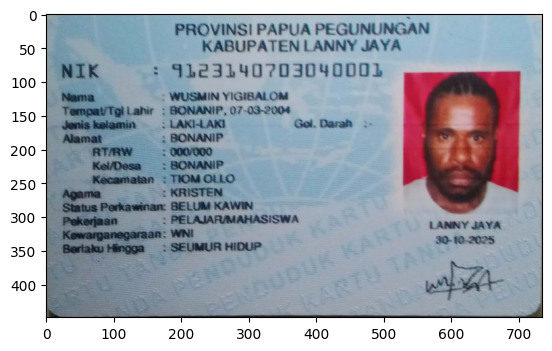

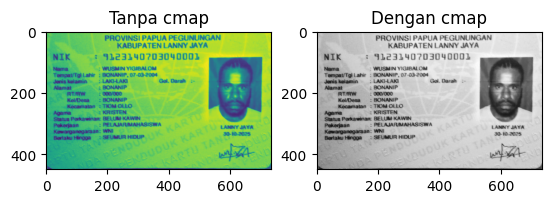

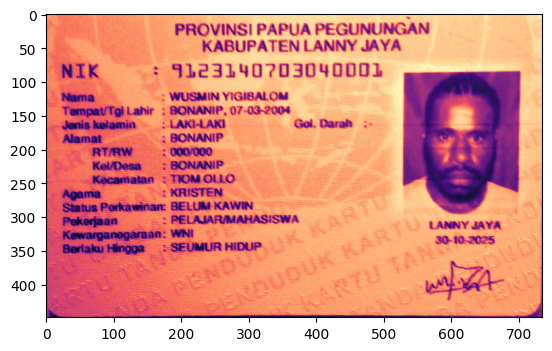

In [20]:
#Menampilkan gambar dengan matplotlib + format warna BGR

import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')
plt.imshow(img) #Format Warna BGR

print('\n')
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB)) #Format Warna RGB
plt.show()

#Grayscale
img_gray = cv.imread('ktp.jpg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

plt.imshow(img_gray, cmap = 'magma')

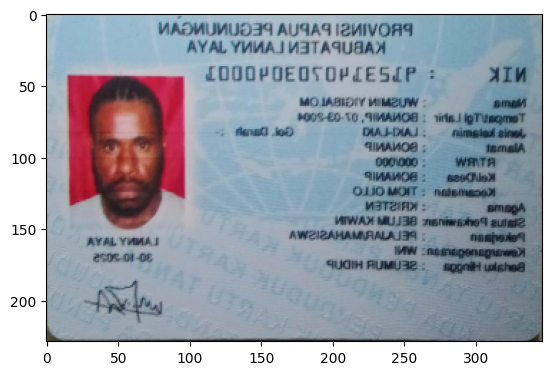

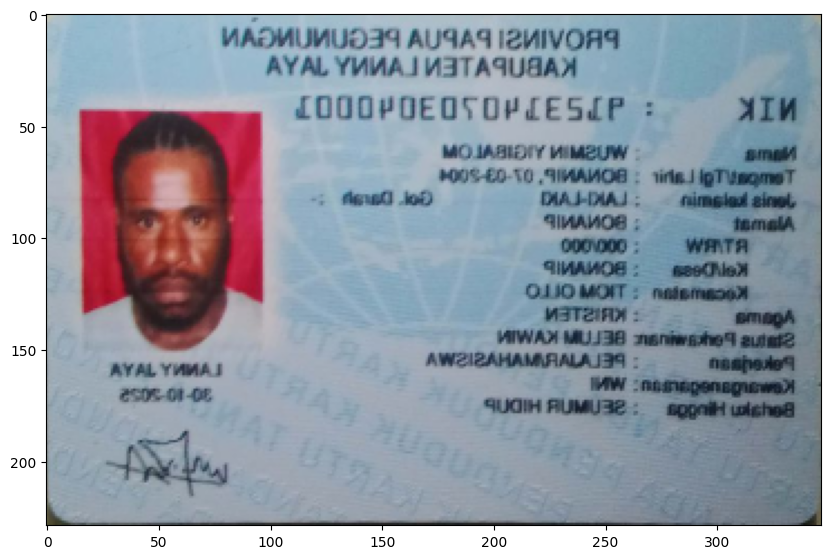

In [23]:
#Resize
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konveri BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

#Melakukan Flipping
imgFlip = cv.flip(img_output,1)
plt.imshow(imgFlip)

#Tampilan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

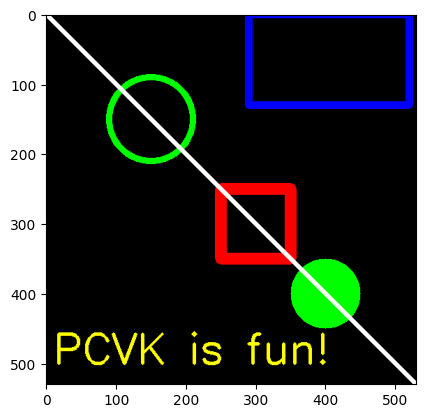

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

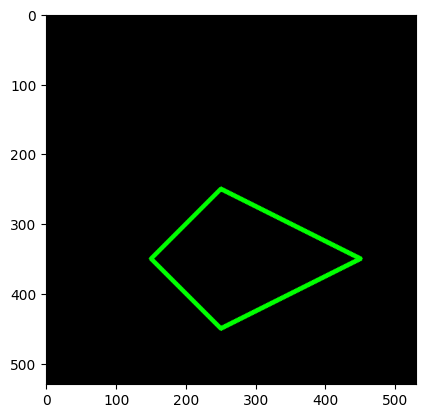

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

black_img2 = np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

vertices = np.array([[150,350],[250,250],[450,350],[250,450]], dtype=np.int32)
vertices

pts = vertices.reshape((-1,1,2))
pts

cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

PERTANYAAN PRAKTIKUM

1. cv2.imread() membaca citra dalam format urutan kanal BGR (Blue, Green, Red). cv2_imshow() dirancang untuk mengenali format BGR tersebut, sedangkan matplotlib (plt.imshow()) membaca dan merender citra berdasarkan standar urutan RGB (Red, Green, Blue) sehingga warna pada plt.imshow() akan terlihat tertukar (kebiruan).

2. Tampilan visual keduanya sama persis (berwarna hitam pekat karena bernilai 0). Namun, ukuran memori (nbytes) berbeda secara signifikan: int16 menggunakan alokasi 2 byte per elemen, sedangkan int32 menggunakan alokasi 4 byte per elemen

3. Fungsi cv2.imshow() bawaan OpenCV bergantung pada sistem GUI. Karena Google Colab berjalan di server cloud berbasis web, fungsi bawaan tersebut akan memicu error atau crash. cv2_imshow dari pustaka google.colab.patches dimodifikasi khusus agar dapat merender dan menampilkan citra langsung di dalam sel notebook browser.

4. skimage.io.imread() membaca citra secara otomatis dalam format RGB (warna sebenarnya), sedangkan cv2.cvtColor(img, cv2.COLOR_BGR2RGB) mengubah citra OpenCV dari BGR menjadi RGB. Keduanya sama-sama menampilkan warna sebenarnya karena sama-sama berformat RGB. Sementara itu, citra mentah dari cv2.imread() tanpa konversi adalah yang kanal warnanya tertukar (BGR).

5. Nilai img.shape tidak berubah sama sekali. Parameter figsize pada Matplotlib hanya mengatur dimensi ukuran kotak/kanvas penampil (display window) di antarmuka grafik, bukan mengubah dimensi matriks piksel atau resolusi asli dari citra itu sendiri.

Tampilan dengan cv2_imshow:


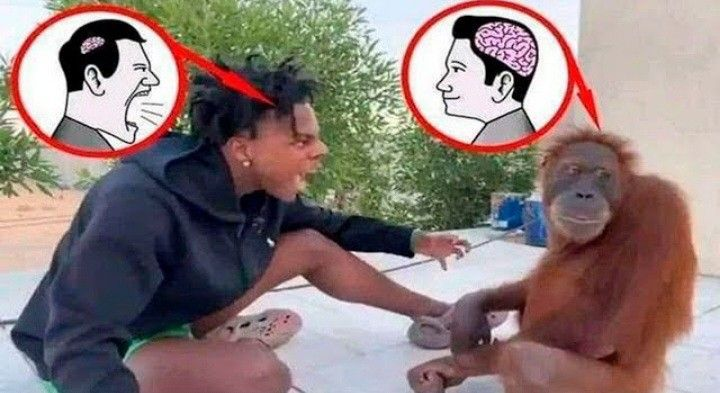

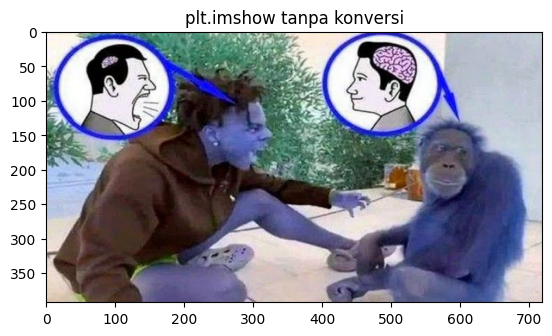

Nilai piksel pada (100, 100): [241 236 245]


--- Kanvas int16 ---
dtype: int16
min: 0
max: 0
nbytes: 540000 bytes

--- Kanvas int32 ---
dtype: int32
min: 0
max: 0
nbytes: 1080000 bytes


Nilai piksel skimage di (100, 100): [245 236 241]
Nilai piksel cv2_rgb di (100, 100): [245 236 241]


Shape sebelum plt.figure: (393, 720, 3)


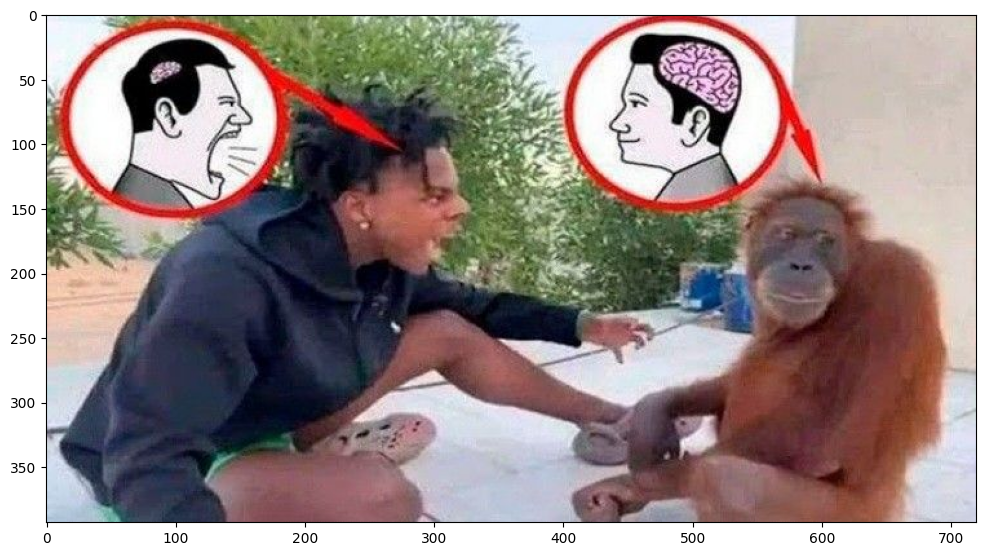

Shape setelah plt.figure: (393, 720, 3)


In [27]:
#SOAL NO.1

import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/gambar1.jpg')

# Tampilkan dengan cv2_imshow (format BGR)
print("Tampilan dengan cv2_imshow:")
cv2_imshow(img)

# Tampilan dengan plt.imshow tanpa konversi (interpretasi RGB)
plt.imshow(img)
plt.title("plt.imshow tanpa konversi")
plt.show()

# Bukti nilai piksel pada posisi (100, 100)
print("Nilai piksel pada (100, 100):", img[100, 100])
print('\n')

#------------------------------------------------------------
#SOAL NO. 2

import numpy as np

# Membuat kanvas hitam ukuran (300, 300, 3)
canvas_int16 = np.zeros((300, 300, 3), dtype=np.int16)
canvas_int32 = np.zeros((300, 300, 3), dtype=np.int32)

print("--- Kanvas int16 ---")
print("dtype:", canvas_int16.dtype)
print("min:", canvas_int16.min())
print("max:", canvas_int16.max())
print("nbytes:", canvas_int16.nbytes, "bytes")

print("\n--- Kanvas int32 ---")
print("dtype:", canvas_int32.dtype)
print("min:", canvas_int32.min())
print("max:", canvas_int32.max())
print("nbytes:", canvas_int32.nbytes, "bytes")
print('\n')

#------------------------------------------------------------
#SOAL NO. 4

import skimage.io
import cv2

# Membaca dengan skimage (format RGB)
img_skimage = skimage.io.imread('/content/drive/MyDrive/PCVK/gambar1.jpg')

# Membaca dengan OpenCV lalu dikonversi ke RGB
img_cv2 = cv2.imread('/content/drive/MyDrive/PCVK/gambar1.jpg')
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

print("Nilai piksel skimage di (100, 100):", img_skimage[100, 100])
print("Nilai piksel cv2_rgb di (100, 100):", img_cv2_rgb[100, 100])
print('\n')

#------------------------------------------------------------
#SOAL NO. 5
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('/content/drive/MyDrive/PCVK/gambar1.jpg')
print("Shape sebelum plt.figure:", img.shape)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

print("Shape setelah plt.figure:", img.shape)

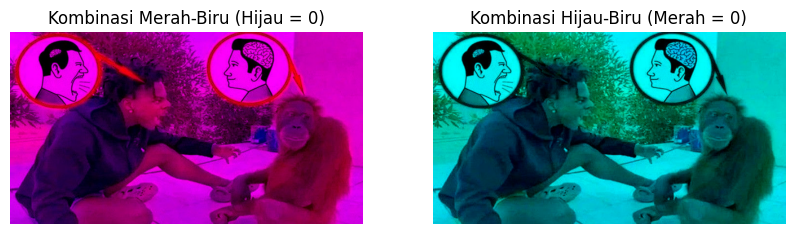

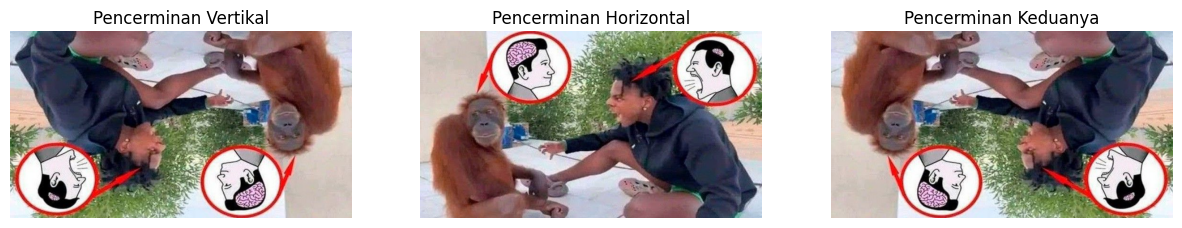

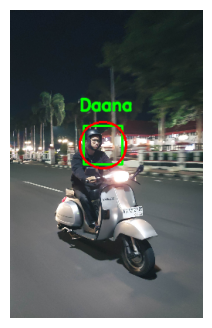

In [37]:
#TUGAS PRAKTIKUM

import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('/content/drive/MyDrive/PCVK/gambar1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Kombinasi Merah-Biru
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# 2. Kombinasi Hijau-Biru
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

# Menampilkan berdampingan dalam satu figure
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kombinasi Merah-Biru (Hijau = 0)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kombinasi Hijau-Biru (Merah = 0)')
plt.axis('off')

plt.show()
print('\n')

#------------------------------------------------------
# Pencerminan vertikal, horizontal, dan keduanya
img_vertical = cv2.flip(img_rgb, 0)
img_horizontal = cv2.flip(img_rgb, 1)
img_both = cv2.flip(img_rgb, -1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_vertical)
plt.title('Pencerminan Vertikal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_horizontal)
plt.title('Pencerminan Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_both)
plt.title('Pencerminan Keduanya')
plt.axis('off')

plt.show()
print('\n')

#------------------------------------------------------
img_face = imgVespaRGB_small.copy()

cv.rectangle(img_face, pt1=(95, 150), pt2=(145, 200), color=(0, 255, 0), thickness=2)
cv.circle(img_face, center=(120, 175), radius=30, color=(255, 0, 0), thickness=2)

font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_face, text='Daana', org=(90, 130), fontFace=font, fontScale=0.7,
            color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)

plt.figure(figsize=(6, 4))
plt.imshow(img_face)
plt.axis('off')
plt.show()

In [38]:
#RANCANGAN ANALISA
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
total_pixels = gray_img.size
bright_pixels = np.sum(gray_img > 150)
percentage = (bright_pixels / total_pixels) * 100

print(f"Total piksel keseluruhan: {total_pixels}")
print(f"Jumlah piksel dengan intensitas > 150: {bright_pixels}")
print(f"Persentase piksel terang: {percentage:.2f}%")

Total piksel keseluruhan: 282960
Jumlah piksel dengan intensitas > 150: 106109
Persentase piksel terang: 37.50%


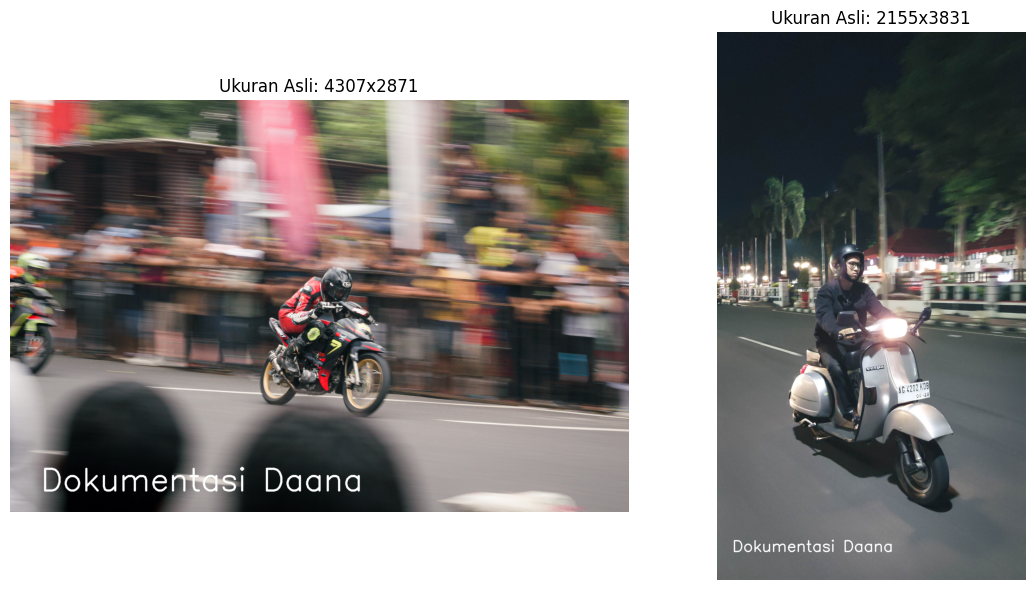

In [46]:
#TUGAS PRAKTIKUM APLIKASI
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Daftar path dua foto dengan ukuran berbeda
path_list = [
    "/content/drive/MyDrive/PCVK/balap.jpg",
    "/content/drive/MyDrive/PCVK/vespa.jpg"
]

plt.figure(figsize=(12, 6))

for i, path in enumerate(path_list):
    # 1. Membaca berkas dan konversi warna
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Mendapatkan ukuran citra secara dinamis (adaptif)
    h, w, c = img_rgb.shape

    # 3. Menghitung posisi, ukuran bar, dan ukuran huruf berdasarkan dimensi citra
    bar_height = int(h * 0.15)        # Tinggi bar proporsional (15% dari tinggi gambar)
    font_scale = max(0.5, w / 600.0)  # Skala huruf adaptif berdasarkan lebar gambar
    thickness = max(1, int(w / 300.0))  # Ketebalan garis adaptif

    # Membuat salinan gambar untuk area label
    img_labeled = img_rgb.copy()

    # Menambahkan teks identitas secara proporsional
    text = "Dokumentasi Daana"
    org = (int(w * 0.05), h - int(bar_height * 0.35))

    cv2.putText(
        img_labeled,
        text=text,
        org=org,
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=font_scale,
        color=(255, 255, 255),
        thickness=thickness,
        lineType=cv2.LINE_AA
    )

    # 4. Menampilkan hasil subplot berdampingan
    plt.subplot(1, 2, i + 1)
    plt.imshow(img_labeled)
    plt.title(f"Ukuran Asli: {w}x{h}")
    plt.axis('off')

plt.tight_layout()
plt.show()